#### 1. Load the two CSV files

In [3]:
import pandas as pd

# Load student-mat and student-por
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

# Check their shapes
print("Math dataset shape:", mat.shape)
print("Portuguese dataset shape:", por.shape)

Math dataset shape: (395, 33)
Portuguese dataset shape: (649, 33)


#### 2. Add a subject column to keep track

In [5]:
mat['subject'] = 'Math'
por['subject'] = 'Portuguese'

#### 3. Combine the two datasets

In [7]:
# Combine using concat
df = pd.concat([mat, por], ignore_index=True)

# Check combined shape
print("Combined dataset shape:", df.shape)

Combined dataset shape: (1044, 34)


#### 4. Handle missing value

In [9]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
dtype: int64

#### 5. Create the binary target variable (Pass/Fail)

In [12]:
# Convert G3 to Pass/Fail
df['pass_fail'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')

# Preview the changes
df[['G3', 'pass_fail']].head()

,G3,pass_fail
0,6,Fail
1,6,Fail
2,10,Pass
3,15,Pass
4,10,Pass


#### 6. Drop G1, G2, G3 to avoid leakage

In [15]:
# Remove grade columns
df = df.drop(columns=['G1', 'G2', 'G3'])

#### 7. Encode all categorical columns

In [20]:
from sklearn.preprocessing import LabelEncoder

# Create encoders for each object column
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Check that all data is now numeric
df.dtypes


school        int32
sex           int32
age           int64
address       int32
famsize       int32
Pstatus       int32
Medu          int64
Fedu          int64
Mjob          int32
Fjob          int32
reason        int32
guardian      int32
traveltime    int64
studytime     int64
failures      int64
schoolsup     int32
famsup        int32
paid          int32
activities    int32
nursery       int32
higher        int32
internet      int32
romantic      int32
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
subject       int32
pass_fail     int32
dtype: object

#### 8. Split into features(X) and target(Y)

In [22]:
# Define features and target
X = df.drop(columns=['pass_fail'])
y = df['pass_fail']

#### 9. Normalize features for KNN

In [26]:
from sklearn.preprocessing import StandardScaler

# Standardize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 10. Split into training and testing sets

In [29]:
from sklearn.model_selection import train_test_split

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (730, 31)
Testing set: (314, 31)


## KNN and Naive Bayer

#### 1.Import the Model

In [31]:
from sklearn.neighbors import KNeighborsClassifier

#### 2. Initialize the Classifier

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)

#### 3. Train the Model

In [35]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

#### 4. Make Predictions

In [37]:
y_pred_knn = knn.predict(X_test)

## Naive Bayer

#### 1. Import Model

In [39]:
from sklearn.naive_bayes import GaussianNB

#### 2. Initialize the Classifier

In [41]:
nb = GaussianNB()

#### 3. Train the Model

In [43]:
nb.fit(X_train, y_train)

GaussianNB()

#### 4. Make Prediction

In [45]:
y_pred_nb = nb.predict(X_test)

### KNN Evaluation

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# --- KNN Evaluation ---
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label=1)
recall_knn = recall_score(y_test, y_pred_knn, pos_label=1)
f1_knn = f1_score(y_test, y_pred_knn, pos_label=1)
confusion_knn = confusion_matrix(y_test, y_pred_knn)

print(accuracy_knn)
print(precision_knn)
print(recall_knn)
print(f1_knn)

0.7643312101910829
0.7785467128027682
0.9574468085106383
0.8587786259541985


### Naive Bayes Evaluation

In [79]:
# --- Naive Bayes Evaluation ---
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label=1)
recall_nb = recall_score(y_test, y_pred_nb, pos_label=1)
f1_nb = f1_score(y_test, y_pred_nb, pos_label=1)
confusion_nb = confusion_matrix(y_test, y_pred_nb)

print(accuracy_nb)
print(precision_nb)
print(recall_nb)
print(f1_nb)

0.7643312101910829
0.8259109311740891
0.8680851063829788
0.8464730290456431


#### Bar Chart

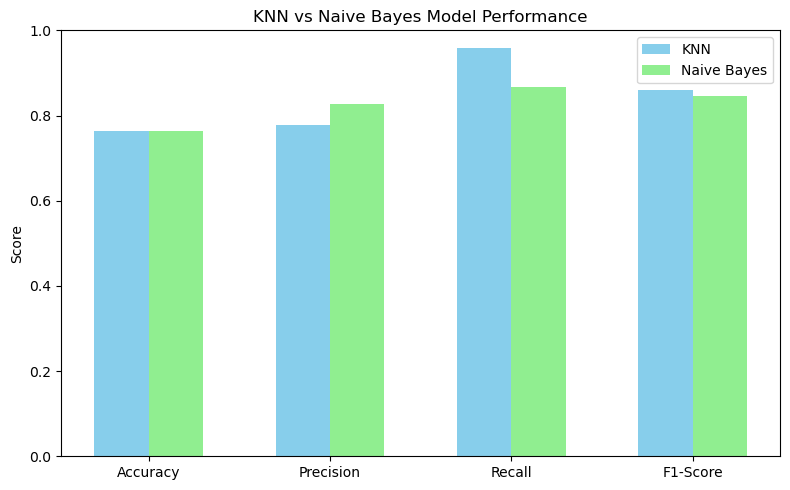

In [72]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
knn_values = [accuracy_knn, precision_knn, recall_knn, f1_knn]
nb_values = [accuracy_nb, precision_nb, recall_nb, f1_nb]

x = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, knn_values, width, label='KNN', color='skyblue')
plt.bar(x + width/2, nb_values, width, label='Naive Bayes', color='lightgreen')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('KNN vs Naive Bayes Model Performance')
plt.legend()
plt.tight_layout()
plt.show()


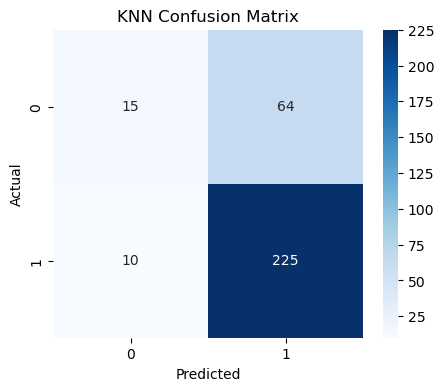

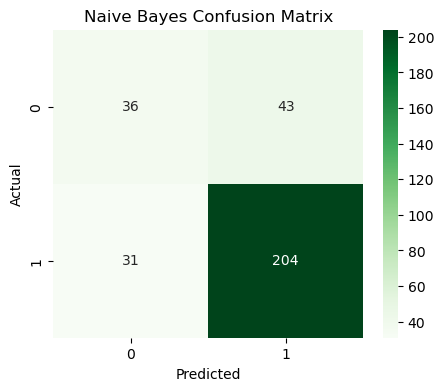

In [75]:
import seaborn as sns

# KNN
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_knn, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Naive Bayes
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_nb, annot=True, fmt='d', cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
